# LSEG Data Pull — NetPayout

Dieses Notebook nutzt nur den `lseg_series_puller`.

Pipeline:
- `1.` Setup
- `2.` Input + Run-Konfiguration
- `3.` Optionaler Reset (Fresh Run)
- `4.` Standard-Puller-Setup
- `5.` NP1 Pull (Balance Sheet)
- `6.` NP2 Pull (Income Statement)
- `7.` NP3 Pull (Payout + Liquidity)
- `8.` Quick Check



## 0. Setup



In [25]:
from pathlib import Path
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lseg_series_puller import (
    SeriesPullConfig,
    SeriesFieldSpec,
    run_standard_pull,
)
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

warnings.filterwarnings("ignore", category=FutureWarning, module="lseg")
pd.set_option("display.max_columns", 200)
set_global_plot_style()


## 2. Input + Run-Konfiguration

Geladene Basisdaten:
- `Project_Data/intermediate/euro500.parquet`

Verwendete Schlüsselspalten:
- `firm_id`
- `date`
- (ID-Fallback aus vorhandenen Spalten wie `ISIN`, `RIC_current`, `RIC`, `id_type`, `pull_id`)



In [26]:
BASE_DIR = Path('/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data')
DATA_DIR = BASE_DIR / 'intermediate'
CACHE_DATA_DIR = BASE_DIR / 'cache'
CACHE_DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_PATH = DATA_DIR / 'euro500.parquet'
OUTPUT_PATH = DATA_DIR / 'euro500_netpayout.parquet'

if not BASE_PATH.exists():
    raise FileNotFoundError(f'Missing file: {BASE_PATH}')

base = pd.read_parquet(BASE_PATH).copy()
if 'date' not in base.columns or 'firm_id' not in base.columns:
    raise ValueError('euro500.parquet must contain at least firm_id and date columns.')

print('Loaded base:', BASE_PATH)
print('rows:', len(base), '| companies:', base['firm_id'].nunique())
print('date range:', pd.to_datetime(base['date'], errors='coerce').min(), '->', pd.to_datetime(base['date'], errors='coerce').max())

# ---------- Run control ----------
# Für komplettes Neuziehen: beide Flags auf True lassen.
RESET_PULL_STATE = False
FORCE_REFRESH_ALL = False
RUN_LSEG_PULL = True
BATCH_SIZE = 10
ASOF_TOL_DAYS = 365
DEBUG_RAW_FIRST_N = 0
PRE_INDEX_PREFETCH_YEARS = 2

# Wenn True, wird auch das finale Output-Parquet entfernt und neu aufgebaut.
RESET_OUTPUT_FILE = False





Loaded base: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
rows: 56500 | companies: 1248
date range: 1997-12-31 00:00:00 -> 2025-12-31 00:00:00


## 3. Reset (optional, für kompletten Neu-Pull)

Wenn aktiviert, werden pro Modul (`NP1/NP2/NP3`) gelöscht:
- Cache-Verzeichnisse (`*_cache_by_company_id`)
- `step_rows`-Dateien
- `checkpoint`-Dateien
- `bad_ids`-Dateien
- `bad_rows`-Logs
- optional das kombinierte Output-File `euro500_netpayout.parquet`



In [27]:
MODULES = {
    'NP1': {
        'cache_dir': CACHE_DATA_DIR / 'np1_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np1_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np1_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np1_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np1_bad_rows.parquet',
    },
    'NP2': {
        'cache_dir': CACHE_DATA_DIR / 'np2_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np2_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np2_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np2_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np2_bad_rows.parquet',
    },
    'NP3': {
        'cache_dir': CACHE_DATA_DIR / 'np3_cache_by_company_id',
        'step_rows_path': CACHE_DATA_DIR / 'np3_step_rows.parquet',
        'checkpoint_path': CACHE_DATA_DIR / 'np3_checkpoint.json',
        'bad_ids_path': CACHE_DATA_DIR / 'np3_bad_ids.csv',
        'bad_rows_log_path': CACHE_DATA_DIR / 'np3_bad_rows.parquet',
    },
}

if RESET_PULL_STATE:
    print('Resetting NP pull state...')
    for name, m in MODULES.items():
        if m['cache_dir'].exists():
            shutil.rmtree(m['cache_dir'])
            print(f'  removed cache dir: {m["cache_dir"]}')
        for k in ['step_rows_path', 'checkpoint_path', 'bad_ids_path', 'bad_rows_log_path']:
            fp = m[k]
            if fp.exists():
                fp.unlink()
                print(f'  removed {name} {k}: {fp}')

if RESET_OUTPUT_FILE and OUTPUT_PATH.exists():
    OUTPUT_PATH.unlink()
    print('Removed old output:', OUTPUT_PATH)


## 4. Standard Puller Setup


In [28]:
def run_np_module(
    source_df: pd.DataFrame,
    module_name: str,
    specs: tuple[SeriesFieldSpec, ...],
    primary_output_col: str,
) -> dict:
    m = MODULES[module_name]

    cfg = SeriesPullConfig(
        batch_size=BATCH_SIZE,
        asof_tolerance_days=ASOF_TOL_DAYS,
        prefetch_start_days=int(PRE_INDEX_PREFETCH_YEARS * 365),
        debug_raw_first_n=DEBUG_RAW_FIRST_N,
        force_refresh=FORCE_REFRESH_ALL,
        cache_only=(not RUN_LSEG_PULL),
        skip_known_bad_ids=True,
        max_retries=3,
        base_sleep_sec=0.7,
        series_specs=specs,
        primary_output_col=primary_output_col,
    )

    print('\n' + '=' * 90)
    print(f'RUN {module_name}')
    print('=' * 90)

    res = run_standard_pull(
        pull_type='series',
        source_df=source_df,
        config=cfg,
        cache_dir=m['cache_dir'],
        step_rows_path=m['step_rows_path'],
        checkpoint_path=m['checkpoint_path'],
        bad_ids_path=m['bad_ids_path'],
        bad_rows_log_path=m['bad_rows_log_path'],
        skip_filled_primary=False,
        merge_back=True,
        diag_prefix=f'{module_name.lower()}_',
    )

    print(f"{module_name} stats:", res['stats'])
    return res


NP1_SPECS = (
    SeriesFieldSpec(output_col='BE', fields=('TR.F.COMEQTOT(Period=FY0)',)),
    SeriesFieldSpec(output_col='assets', fields=('TR.F.TOTASSETS(Period=FY0)',)),
    SeriesFieldSpec(output_col='debt', fields=('TR.F.DEBTTOT(Period=FY0)',)),
)

NP2_SPECS = (
    SeriesFieldSpec(output_col='Sales', fields=('TR.F.TotRevenue(Period=FY0)',)),
    SeriesFieldSpec(output_col='NetIncome', fields=('TR.F.NetIncAfterTax(Period=FY0)',)),
    SeriesFieldSpec(output_col='GrossProfit', fields=('TR.F.GrossProfIndPropTot(Period=FY0)',)),
    SeriesFieldSpec(output_col='Cogs', fields=('TR.F.COGSTot(Period=FY0)',)),
)

# CashSTInvst ist bewusst in NP3 integriert.
NP3_SPECS = (
    SeriesFieldSpec(output_col='Dividends', fields=('TR.F.DivPaidCashTotCF(Period=FY0)',)),
    SeriesFieldSpec(output_col='Buybacks', fields=('TR.F.ComStockBuybackNet(Period=FY0)',)),
    SeriesFieldSpec(output_col='CashSTInvst', fields=('TR.F.CashSTInvst(Period=FY0)',)),
)


def coverage_by_quarter(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    x = df.copy()
    x['date'] = pd.to_datetime(x['date'], errors='coerce').dt.normalize()
    x = x.dropna(subset=['firm_id', 'date']).copy()
    x['quarter'] = x['date'].dt.to_period('Q').dt.to_timestamp(how='end').dt.normalize()

    rows = []
    for q, g in x.groupby('quarter', sort=True):
        rec = {
            'quarter': q,
            'n_obs': int(len(g)),
            'n_firms': int(g['firm_id'].nunique()),
        }
        for col in cols:
            if col in g.columns:
                rec[f'cov_{col}_pct'] = round(float(pd.to_numeric(g[col], errors='coerce').notna().mean() * 100.0), 2)
            else:
                rec[f'cov_{col}_pct'] = np.nan
        rows.append(rec)

    out = pd.DataFrame(rows).sort_values('quarter').reset_index(drop=True)
    return out







## 5. NP1 (Balance Sheet)

In NP1 geladene LSEG-Daten (FY):
- `TR.F.COMEQTOT(Period=FY0)` -> `BE`
- `TR.F.TOTASSETS(Period=FY0)` -> `assets`
- `TR.F.DEBTTOT(Period=FY0)` -> `debt`

Merge-Ziel:
- zurück auf `euro500` über `firm_id,date`



In [29]:
np1 = run_np_module(base, 'NP1', NP1_SPECS, primary_output_col='BE')
np1_df = np1['merged_df'].copy()
print('NP1 done: rows=', len(np1_df), '| companies=', np1_df['firm_id'].nunique())



RUN NP1

Standard Series Pull Overview
series_specs: BE<-['TR.F.COMEQTOT(Period=FY0)'], assets<-['TR.F.TOTASSETS(Period=FY0)'], debt<-['TR.F.DEBTTOT(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=802 | partial_coverage=313 | bad_ids=133 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_BE=0, full_coverage=802, partial_coverage=313, bad_ids=133, bad_id_skip=133, bad_ids_added=0, known_bad_ids_now=133
NP1 stats: {'companies_total': 1248, 'full_coverage': 802, 'partial_coverage': 313, 'bad_ids': 133, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 133, 'bad_ids_added': 0, 'known_bad_ids_now': 133}
NP1 done: rows= 56500 | companies= 1248


### 5.1 NP1 Coverage nach Quartal



In [30]:
np1_cov_q = coverage_by_quarter(np1_df, ['BE', 'assets', 'debt'])
np1_cov_q

,quarter,n_obs,n_firms,cov_BE_pct,cov_assets_pct,cov_debt_pct
0,1997-12-31,500,500,62.2,62.4,59.8
1,1998-03-31,500,500,66.4,66.6,64.4
2,1998-06-30,500,500,68.8,69.2,67.0
3,1998-09-30,500,500,70.8,71.2,69.2
4,1998-12-31,500,500,88.4,88.6,85.4
...,...,...,...,...,...,...
108,2024-12-31,500,500,97.6,97.6,97.2
109,2025-03-31,500,500,98.8,98.8,98.4
110,2025-06-30,500,500,99.0,99.0,98.6
111,2025-09-30,500,500,98.6,98.6,98.2


## 6. NP2 (Income Statement)

In NP2 geladene LSEG-Daten (FY):
- `TR.F.TotRevenue(Period=FY0)` -> `Sales`
- `TR.F.NetIncAfterTax(Period=FY0)` -> `NetIncome`
- `TR.F.GrossProfIndPropTot(Period=FY0)` -> `GrossProfit`
- `TR.F.COGSTot(Period=FY0)` -> `Cogs`

Merge-Ziel:
- Update des NP1-Outputs über `firm_id,date`



In [31]:
_np2_input = np1_df if 'np1_df' in globals() else base
np2 = run_np_module(_np2_input, 'NP2', NP2_SPECS, primary_output_col='Sales')
np2_df = np2['merged_df'].copy()
print('NP2 done: rows=', len(np2_df), '| companies=', np2_df['firm_id'].nunique())



RUN NP2

Standard Series Pull Overview
series_specs: Sales<-['TR.F.TotRevenue(Period=FY0)'], NetIncome<-['TR.F.NetIncAfterTax(Period=FY0)'], GrossProfit<-['TR.F.GrossProfIndPropTot(Period=FY0)'], Cogs<-['TR.F.COGSTot(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=821 | partial_coverage=279 | bad_ids=148 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_Sales=0, full_coverage=821, partial_coverage=279, bad_ids=148, bad_id_skip=148, bad_ids_added=0, known_bad_ids_now=148
NP2 stats: {'companies_total': 1248, 'full_coverage': 821, 'partial_coverage': 279, 'bad_ids': 148, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 148, 'bad_ids_added': 0, 'known_bad_ids_now': 148}
NP2 done: rows= 56500 | companies= 1248


### 6.1 NP2 Coverage nach Quartal



In [32]:
np2_cov_q = coverage_by_quarter(np2_df, ['Sales', 'NetIncome', 'GrossProfit', 'Cogs'])
np2_cov_q


,quarter,n_obs,n_firms,cov_Sales_pct,cov_NetIncome_pct,cov_GrossProfit_pct,cov_Cogs_pct
0,1997-12-31,500,500,61.0,61.2,54.4,48.6
1,1998-03-31,500,500,65.2,65.2,58.2,52.0
2,1998-06-30,500,500,67.8,67.8,60.8,54.2
3,1998-09-30,500,500,69.8,69.8,62.8,56.4
4,1998-12-31,500,500,86.2,86.4,77.8,72.4
...,...,...,...,...,...,...,...
108,2024-12-31,500,500,96.0,96.2,82.6,78.4
109,2025-03-31,500,500,97.2,97.4,84.0,79.8
110,2025-06-30,500,500,97.4,97.6,84.2,80.0
111,2025-09-30,500,500,97.0,97.2,83.4,79.0


## 7. NP3 (Payout + Liquidity)

In NP3 geladene LSEG-Daten (FY):
- `TR.F.DivPaidCashTotCF(Period=FY0)` -> `Dividends`
- `TR.F.ComStockBuybackNet(Period=FY0)` -> `Buybacks`
- `TR.F.CashSTInvst(Period=FY0)` -> `CashSTInvst`

Merge-Ziel:
- Update des NP2-Outputs über `firm_id,date`
- finaler Export nach `Project_Data/intermediate/euro500_netpayout.parquet`



In [33]:
_np3_input = np2_df if 'np2_df' in globals() else (np1_df if 'np1_df' in globals() else base)
np3 = run_np_module(_np3_input, 'NP3', NP3_SPECS, primary_output_col='Dividends')
out = np3['merged_df'].copy()
out['date'] = pd.to_datetime(out['date'], errors='coerce').dt.normalize()
out = out.dropna(subset=['firm_id', 'date']).sort_values(['firm_id', 'date']).drop_duplicates(['firm_id', 'date'], keep='last')
euro500_netpayout_df = out.copy()
print('Prepared NP3 merged panel in memory: rows=', len(out), '| companies=', out['firm_id'].nunique())



RUN NP3

Standard Series Pull Overview
series_specs: Dividends<-['TR.F.DivPaidCashTotCF(Period=FY0)'], Buybacks<-['TR.F.ComStockBuybackNet(Period=FY0)'], CashSTInvst<-['TR.F.CashSTInvst(Period=FY0)']
request_rows: 56,500
coverage: all_companies=1,248 | full_coverage=305 | partial_coverage=598 | bad_ids=345 | remaining=0
mode: CACHE+NETWORK | batch_size: 10
Done: companies_total=1248, run_remaining_start=0, candidate_calls=0, resolved_rows=0, unresolved_rows=0, found_Dividends=0, full_coverage=305, partial_coverage=598, bad_ids=345, bad_id_skip=345, bad_ids_added=0, known_bad_ids_now=345
NP3 stats: {'companies_total': 1248, 'full_coverage': 305, 'partial_coverage': 598, 'bad_ids': 345, 'remaining': 0, 'run_remaining_start': 0, 'candidate_calls': 0, 'resolved_rows': 0, 'unresolved_rows': 0, 'bad_id_skip': 345, 'bad_ids_added': 0, 'known_bad_ids_now': 345}
Prepared NP3 merged panel in memory: rows= 56500 | companies= 1248


### 7.1 NP3 Coverage nach Quartal



In [34]:
np3_cov_q = coverage_by_quarter(euro500_netpayout_df, ['Dividends', 'Buybacks', 'CashSTInvst'])
np3_cov_q


,quarter,n_obs,n_firms,cov_Dividends_pct,cov_Buybacks_pct,cov_CashSTInvst_pct
0,1997-12-31,500,500,35.2,23.6,57.4
1,1998-03-31,500,500,37.4,25.4,61.0
2,1998-06-30,500,500,38.0,26.8,63.4
3,1998-09-30,500,500,39.2,27.6,65.4
4,1998-12-31,500,500,52.0,37.2,83.0
...,...,...,...,...,...,...
108,2024-12-31,500,500,87.4,69.6,95.2
109,2025-03-31,500,500,89.4,69.6,96.4
110,2025-06-30,500,500,89.4,70.4,96.6
111,2025-09-30,500,500,88.4,69.6,95.8


## 8. Coverage-Plot nach Quartal

Kombinierte Quartals-Coverage der 9 Kern-Items im Stil von `plot_style.py`:
- `BE`, `assets`, `debt`
- `Sales`, `NetIncome`, `GrossProfit`, `Cogs`
- `Dividends`, `Buybacks`


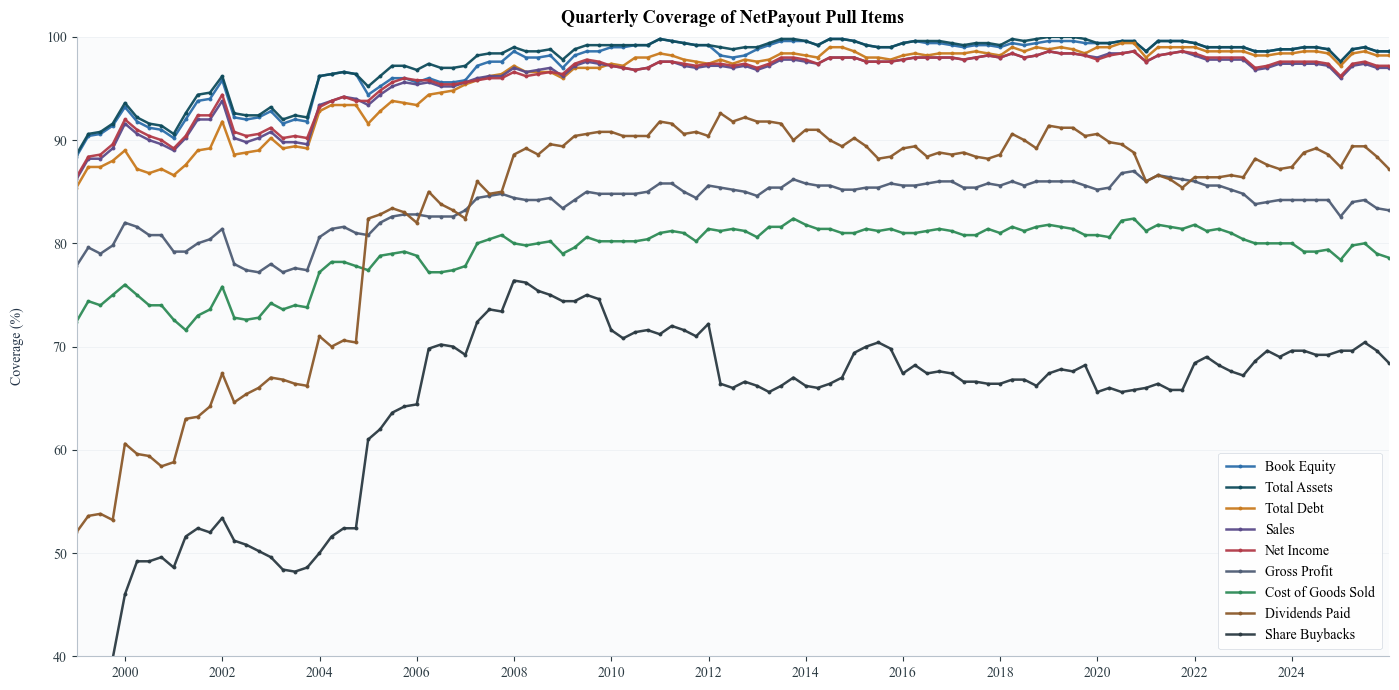

In [35]:
plot_items = [
    ('BE', 'Book Equity'),
    ('assets', 'Total Assets'),
    ('debt', 'Total Debt'),
    ('Sales', 'Sales'),
    ('NetIncome', 'Net Income'),
    ('GrossProfit', 'Gross Profit'),
    ('Cogs', 'Cost of Goods Sold'),
    ('Dividends', 'Dividends Paid'),
    ('Buybacks', 'Share Buybacks'),
]

coverage_frames = [
    np1_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['BE', 'assets', 'debt']]].copy(),
    np2_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Sales', 'NetIncome', 'GrossProfit', 'Cogs']]].copy(),
    np3_cov_q[['quarter'] + [f'cov_{c}_pct' for c in ['Dividends', 'Buybacks']]].copy(),
]

coverage_plot_df = coverage_frames[0]
for frame in coverage_frames[1:]:
    coverage_plot_df = coverage_plot_df.merge(frame, on='quarter', how='outer')

coverage_plot_df = coverage_plot_df.sort_values('quarter').reset_index(drop=True)

line_colors = [
    COLORS['blue'],
    COLORS['primary'],
    COLORS['orange'],
    COLORS['purple'],
    COLORS['accent'],
    COLORS['neutral'],
    COLORS['green'],
    COLORS['brown'],
    COLORS['reference'],
]

fig, ax = plt.subplots(figsize=(14, 7))

for (item, label), color in zip(plot_items, line_colors):
    col = f'cov_{item}_pct'
    if col not in coverage_plot_df.columns:
        continue
    ax.plot(
        coverage_plot_df['quarter'],
        coverage_plot_df[col],
        label=label,
        color=color,
        linewidth=1.8,
        marker='o',
        markersize=2.8,
        markeredgewidth=0.0,
        alpha=0.95,
    )

ax.set_title('Quarterly Coverage of NetPayout Pull Items')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(40, 100)

style_axes(ax, grid_axis='y', grid_alpha=0.3)
style_time_axis(
    ax,
    x_min=coverage_plot_df['quarter'].min(),
    x_max=coverage_plot_df['quarter'].max(),
    x_ticks=coverage_plot_df['quarter'],
    date_fmt='%Y',
)
style_legend(ax, loc='lower right', title=None)

graphs_dir = BASE_DIR / 'graphs'
graphs_dir.mkdir(parents=True, exist_ok=True)
coverage_plot_path = graphs_dir / 'netpayout_coverage_quarterly.png'

fig.tight_layout()
fig.savefig(coverage_plot_path, dpi=220, bbox_inches='tight')

plt.show()


## 9. Finaler Output: Full-History als euro500_netpayout

Der einzige Tabellen-Output ist `euro500_netpayout.parquet`.
Er enthaelt die rohe Cache-Historie (eine Zeile je gezogenem `firm_id,date`),
inklusive der verfügbaren NP-Items und firmenstatischer Metadaten aus `euro500.parquet`.


In [36]:
FULL_HISTORY_VALUE_COLS = ['BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst']


def _first_valid(series: pd.Series):
    non_na = series.dropna()
    return non_na.iloc[0] if not non_na.empty else pd.NA


def _load_module_full_history(cache_dir: Path, value_cols: list[str]) -> pd.DataFrame:
    rows = []
    cache_files = sorted(cache_dir.glob('*.parquet'))
    for fp in cache_files:
        try:
            hist = pd.read_parquet(fp).copy()
        except Exception as exc:
            print(f'Skipping unreadable cache file: {fp.name} | {exc}')
            continue

        if 'date' not in hist.columns:
            continue

        firm_id = fp.stem.split('__', 1)[0]
        hist['firm_id'] = firm_id
        hist['date'] = pd.to_datetime(hist['date'], errors='coerce').dt.normalize()
        hist = hist.dropna(subset=['firm_id', 'date']).copy()
        if hist.empty:
            continue

        keep_cols = ['firm_id', 'date'] + [c for c in value_cols if c in hist.columns]
        hist = hist[keep_cols].copy()
        for c in value_cols:
            if c not in hist.columns:
                hist[c] = np.nan
        rows.append(hist[['firm_id', 'date', *value_cols]])

    if not rows:
        return pd.DataFrame(columns=['firm_id', 'date', *value_cols])

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values(['firm_id', 'date']).groupby(['firm_id', 'date'], as_index=False).agg({c: _first_valid for c in value_cols})
    return out.sort_values(['firm_id', 'date']).reset_index(drop=True)


def build_full_history_export(base_df: pd.DataFrame) -> pd.DataFrame:
    module_frames = []
    for module_name, spec in MODULES.items():
        module_value_cols = [s.output_col for s in {'NP1': NP1_SPECS, 'NP2': NP2_SPECS, 'NP3': NP3_SPECS}[module_name]]
        module_hist = _load_module_full_history(spec['cache_dir'], module_value_cols)
        module_frames.append(module_hist)

    full_history = module_frames[0].copy()
    for frame in module_frames[1:]:
        full_history = full_history.merge(frame, on=['firm_id', 'date'], how='outer')

    meta_cols = [c for c in base_df.columns if c not in FULL_HISTORY_VALUE_COLS and c != 'date']
    meta = base_df[meta_cols].copy()
    meta = meta.sort_values('firm_id').groupby('firm_id', as_index=False).agg({c: _first_valid for c in meta_cols if c != 'firm_id'})

    out = full_history.merge(meta, on='firm_id', how='left')
    ordered_cols = [c for c in base_df.columns if c in out.columns and c != 'date']
    ordered_cols = ['firm_id', 'date'] + [c for c in ordered_cols if c != 'firm_id']
    extra_cols = [c for c in out.columns if c not in ordered_cols]
    out = out[ordered_cols + extra_cols]
    out = out.sort_values(['firm_id', 'date']).reset_index(drop=True)
    return out


euro500_netpayout_full_history_df = build_full_history_export(base)
euro500_netpayout_full_history_df.to_parquet(OUTPUT_PATH, index=False)
euro500_netpayout_df = euro500_netpayout_full_history_df.copy()

print('Saved output:', OUTPUT_PATH)
print('rows:', len(euro500_netpayout_full_history_df), '| companies:', euro500_netpayout_full_history_df['firm_id'].nunique())
print('date range:', euro500_netpayout_full_history_df['date'].min(), '->', euro500_netpayout_full_history_df['date'].max())
euro500_netpayout_full_history_df.head()


Saved output: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_netpayout.parquet
rows: 16872 | companies: 1125
date range: 1995-12-30 00:00:00 -> 2025-09-30 00:00:00


,firm_id,date,formation_date,effective_date,quarter,RIC,name,hq_country,hq_code,trbc_sector,trbc_sector_code,mcap_eur,RIC_current,ISIN,SEDOL,first_trade_date,ipo_date,FreeFloat,FreeFloatPct,Volume,shares_outstanding,PriceClose,InstrumentType,Currency,rank_mcap,beta,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst
0,FIRM0000001,1998-11-30,2001-06-29,2001-07-02,2001Q3,AAHG.F,Ahlers AG,Germany,DE,Consumer Cyclicals,53,183193550.0,AAHG.F,DE0005009708,BDFXP10,1989-12-01,1987-06-03,2232350,27.9044,1419,<NA>,12.9,Ordinary Shares,EUR,433,0.473671,92670119.59117,201941375.2729,54100816.53313,296097820.36271,15384772.70519,145027942.10131,151069878.2614,10021320.87145,0.0,20117801.64943
1,FIRM0000001,1999-11-30,2001-06-29,2001-07-02,2001Q3,AAHG.F,Ahlers AG,Germany,DE,Consumer Cyclicals,53,183193550.0,AAHG.F,DE0005009708,BDFXP10,1989-12-01,1987-06-03,2232350,27.9044,1419,<NA>,12.9,Ordinary Shares,EUR,433,0.473671,104237075.81947,264407949.56617,101319133.05349,305313856.52127,15307056.33925,148917850.73345,156396005.78782,<NA>,<NA>,39481959.06597
2,FIRM0000001,2000-11-30,2001-06-29,2001-07-02,2001Q3,AAHG.F,Ahlers AG,Germany,DE,Consumer Cyclicals,53,183193550.0,AAHG.F,DE0005009708,BDFXP10,1989-12-01,1987-06-03,2232350,27.9044,1419,<NA>,12.9,Ordinary Shares,EUR,433,0.473671,108772234.80568,265103817.81648,99152278.06098,379503331.06661,14892398.6236,184504276.95659,194999054.11002,11046972.38513,<NA>,21139362.82806
3,FIRM0000001,2001-11-30,2001-06-29,2001-07-02,2001Q3,AAHG.F,Ahlers AG,Germany,DE,Consumer Cyclicals,53,183193550.0,AAHG.F,DE0005009708,BDFXP10,1989-12-01,1987-06-03,2232350,27.9044,1419,<NA>,12.9,Ordinary Shares,EUR,433,0.473671,108458000.0,259187000.0,94053000.0,379731000.0,12857000.0,183741000.0,195990000.0,11888000.0,<NA>,28166000.0
4,FIRM0000001,2002-11-30,2001-06-29,2001-07-02,2001Q3,AAHG.F,Ahlers AG,Germany,DE,Consumer Cyclicals,53,183193550.0,AAHG.F,DE0005009708,BDFXP10,1989-12-01,1987-06-03,2232350,27.9044,1419,<NA>,12.9,Ordinary Shares,EUR,433,0.473671,107209000.0,251266000.0,86852000.0,350488000.0,12126000.0,173302000.0,177186000.0,11995000.0,<NA>,29037000.0
